In [1]:
%pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --------------------- ------------------ 4.5/8.3 MB 21.9 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 20.1 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 17.6 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   --- ------------------------------------ 3.1/37.3 MB 15.6 MB/s eta 0:00:03
   ------ --------------------------------- 6.3/37.3 MB 15.1 MB/s eta 0:00:03
   ---------- ----------------------------- 9.7/37.3 MB 15.1 MB/s eta 0:00:02
   ------------- -------------------------- 12.3/37.3 MB 14.5 MB/s eta 0:00:02
   ---------------- ----------------------- 15.2/37.3 MB 14.3 MB/s eta 0:00:02
   ------------------ --------------------- 17.0/37.3 MB 


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv("../data/churn_cleaned.csv")
df.shape

(7043, 31)

In [4]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print(X.shape, y.shape)

(7043, 30) (7043,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (5634, 30) Test: (1409, 30)


In [6]:
scaler = StandardScaler()

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [7]:
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Accuracy: 0.7381121362668559
Precision: 0.504302925989673
Recall: 0.7834224598930482
F1 Score: 0.6136125654450262

Confusion Matrix:
 [[747 288]
 [ 81 293]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [11]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7757274662881476
Precision: 0.5687203791469194
Recall: 0.6417112299465241
F1 Score: 0.6030150753768844

Confusion Matrix:
 [[853 182]
 [134 240]]


<Axes: >

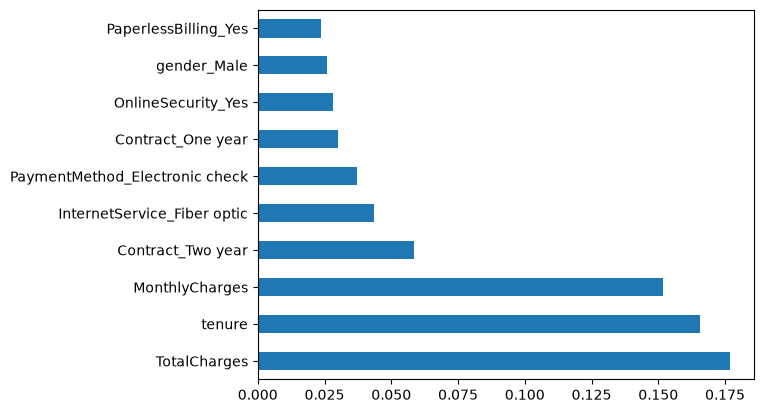

In [12]:
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind="barh")

In [19]:
import os
os.makedirs("../model", exist_ok=True)

In [20]:
import joblib

joblib.dump(log_model, "../model/churn_model.pkl")
joblib.dump(scaler, "../model/scaler.pkl")

['../model/scaler.pkl']

In [21]:
import joblib

# Save the exact column structure the model expects
model_columns = X.columns.tolist()
joblib.dump(model_columns, "../model/model_columns.pkl")

['../model/model_columns.pkl']